# Credit Scoring & Loan Decision System

Import all necessary libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, precision_recall_curve, auc
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import webbrowser
import joblib

import warnings
warnings.filterwarnings('ignore')

In [34]:
df = pd.read_csv("creditscore.csv")
df.head()

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.803,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.122,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.025,63588.0,7,0,1,0,0.0


In [35]:
print("Data shape:", df.shape)

Data shape: (150000, 12)


Explore Dataset

Check for missing values

In [36]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 ID                                          0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
Age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


Check Target Distribution

In [37]:
target_dist = df['SeriousDlqin2yrs'].value_counts(normalize=True)
print(f"Target distribution: {target_dist}")

Target distribution: SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


Plot Target Distribution

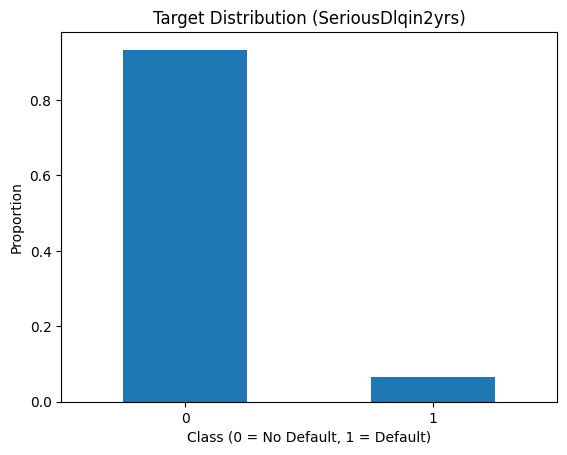

In [38]:
plt.figure()
target_dist.plot(kind='bar')

plt.title('Target Distribution (SeriousDlqin2yrs)')
plt.xlabel('Class (0 = No Default, 1 = Default)')
plt.ylabel('Proportion')

plt.xticks(rotation=0)
plt.show()

Handle Missing Values

1. MonthlyIncome: Impute with median

In [39]:
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)

2. NumberOfDependents: Impute with 0 (or median)

In [40]:
df['NumberOfDependents'].fillna(0, inplace=True)

Crosscheck for null values

In [41]:
print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 ID                                      0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
Age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


Feature Engineering

In [42]:
df['TotalPastDue'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] +
                        df['NumberOfTime60-89DaysPastDueNotWorse'] +
                        df['NumberOfTimes90DaysLate'])

In [43]:
df['DebtPerIncome'] = df['DebtRatio'] * df['MonthlyIncome']

Preparing data for Test/Train Split

In [44]:
X = df.drop(columns=['ID', 'SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

Train/Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

Feature scaling

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Handle imbalanced data with SMOTE

In [47]:
smote = SMOTE(random_state=42)
X_train_lr, y_train_lr = smote.fit_resample(X_train_scaled, y_train)

Logistic Regression with CV

In [48]:
logreg = LogisticRegression(class_weight='balanced', random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for train_idx, val_idx in cv.split(X_train_lr, y_train_lr):
    X_tr, X_val = X_train_lr[train_idx], X_train_lr[val_idx]
    y_tr, y_val = y_train_lr[train_idx], y_train_lr[val_idx]
    
    logreg.fit(X_tr, y_tr)
    y_val_pred = logreg.predict_proba(X_val)[:,1]
    roc = roc_auc_score(y_val, y_val_pred)
    cv_scores.append(roc)

print(f"Logistic Regression CV ROC-AUC scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {np.mean(cv_scores):.4f}")

Logistic Regression CV ROC-AUC scores: [0.778850101595592, 0.7803290427279819, 0.780535389335943, 0.7856847343924562, 0.7804176341013276]
Mean CV ROC-AUC: 0.7812


Train final Logistic Regression on all SMOTE data

In [49]:
logreg.fit(X_train_lr, y_train_lr)
y_proba_logreg = logreg.predict_proba(X_test_scaled)[:,1]

XGBoost with Hyperparameter Tuning

In [50]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [51]:
X_train_xgb = X_train.select_dtypes(include=[np.number])
X_test_xgb  = X_test.select_dtypes(include=[np.number])

In [52]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb.fit(X_train_xgb, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [53]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Best XGBoost parameters:", grid.best_params_)
print("Best XGBoost CV ROC-AUC:", grid.best_score_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best XGBoost parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best XGBoost CV ROC-AUC: 0.864577452385872


Use Best Estimator

In [54]:
xgb_best = grid.best_estimator_
y_proba_xgb = xgb_best.predict_proba(X_test)[:,1]

Model Evaluation Function

In [55]:
def evaluate_model(y_true, y_proba, threshold=0.5, model_name="Model"):
    y_pred = (y_proba >= threshold).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_proba)
    
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)
    
    print(f"\n{model_name} Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Evaluate Both Models


Logistic Regression (SMOTE) Evaluation:
Accuracy: 0.7571
Precision: 0.1707
Recall: 0.6828
F1-score: 0.2731
ROC-AUC: 0.7955
PR-AUC: 0.3160


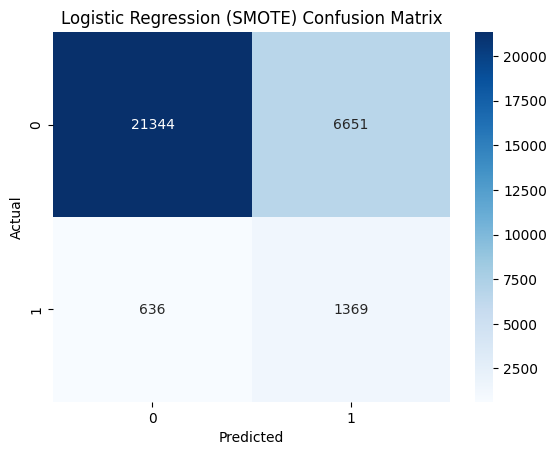


XGBoost Evaluation:
Accuracy: 0.7938
Precision: 0.2147
Recall: 0.7845
F1-score: 0.3372
ROC-AUC: 0.8694
PR-AUC: 0.4056


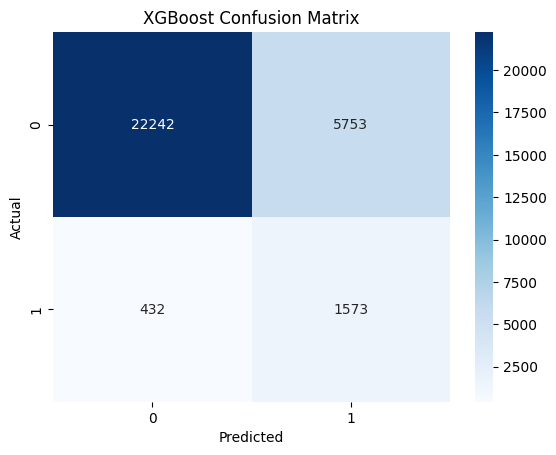

In [56]:
evaluate_model(y_test, y_proba_logreg, model_name="Logistic Regression (SMOTE)")
evaluate_model(y_test, y_proba_xgb, model_name="XGBoost")

SHAP Explainability (XGBoost)

In [57]:
X_test_xgb = X_test.select_dtypes(include=[np.number])

In [58]:
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer(X_test_xgb)

Summary Plot

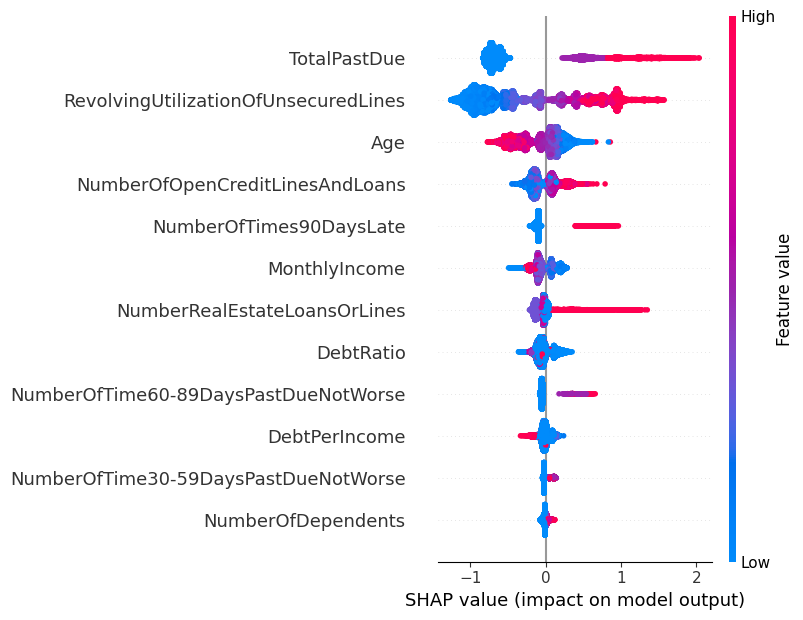

In [59]:
shap.summary_plot(shap_values, X_test_xgb, feature_names=X_test_xgb.columns)

Force plot for first prediction

In [60]:
shap.initjs()

force_plot = shap.force_plot(
    base_value=shap_values.base_values[0],
    shap_values=shap_values.values[0],
    features=X_test_xgb.iloc[0,:],
    feature_names=X_test_xgb.columns
)

shap.save_html("shap_force.html", force_plot)

Model Comparison

In [61]:
roc_logreg = roc_auc_score(y_test, y_proba_logreg)
roc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"ROC-AUC Logistic Regression: {roc_logreg:.4f}")
print(f"ROC-AUC XGBoost: {roc_xgb:.4f}")

if roc_xgb > roc_logreg:
    print("XGBoost performs better.")
else:
    print("Logistic Regression performs better.")

ROC-AUC Logistic Regression: 0.7955
ROC-AUC XGBoost: 0.8694
XGBoost performs better.


Save models and scaler

In [62]:
joblib.dump(logreg, "models/logreg_v2.pkl")
joblib.dump(xgb_best, "models/xgb_best.pkl")
joblib.dump(scaler, "models/scaler_v2.pkl")

print("Models and scaler saved successfully!")

Models and scaler saved successfully!
